In [1]:
from Data_Functions import Get_Data, Extract_Initial_Data, Clean_and_preImpute, Impute_df, FeatureImportance
from Visualization_Functions import plot_Importance
%run Models.ipynb

In [2]:
df = Get_Data('Data/train.csv')
df_test = Get_Data('Data/test.csv')

df, df_test = Extract_Initial_Data(df, df_test, version = 2)

In [3]:
df0_clean, df0_test_clean = Clean_and_preImpute(df, df_test)

Number of null rows before cleaning: 2087 in training data    and 996 in testing data
skewed_features:  ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck', 'GroupSize', 'FamilySize', 'GroupFamilySize', 'CabinFamilySize', 'CabinGroupSize', 'CabinSize', 'ppId']
There are 1371 remaining null rows in training data after cleaning
and 684 remaining null rows in test data


In [4]:
Destination_Features = [col for col in df0_clean.columns if col.startswith('Destination_')]
HomePlanet_Features = [col for col in df0_clean.columns if col.startswith('HomePlanet_')]
deck_Features = [col for col in df0_clean.columns if col.startswith('deck_')]
Region_Features = [col for col in df0_clean.columns if col.startswith('Region_')]
Batch_Features = [col for col in df0_clean.columns if col.startswith('Batch_')]
cols_to_drop = ['Last Name', 'Cabin', 'Cabin Number', 'GroupId', 'Age_LifeStages_lbs', 'Age', 'Under_13', 'HomePlanet', 'deck', 'side_P', 'side']
cols_to_drop += HomePlanet_Features + deck_Features + Region_Features + Batch_Features

df_clean, df_test_clean = Impute_df(df0_clean, df0_test_clean, impute_method = 'Impute', columns_to_drop = cols_to_drop)

In [5]:
X = df_clean.drop(columns = ['Transported']).copy()
y = df_clean['Transported'].copy()

X_test = df_test_clean.copy()

In [6]:
Nominal_Categorical_Features = ['HomePlanetDeck', 'Destination']
ohe_cols = [f'{col}_{c}' for col in Nominal_Categorical_Features for c in X[col].unique()]
Binary_Features = [feature for feature in X.drop(columns = ohe_cols).select_dtypes(include = ['object', 'int', 'bool']) if set(X[feature].unique()).issubset({'True', 'False', 0, 1})]
Ordinal_Categorical_Features = [feature for feature in X.drop(columns = ohe_cols + Binary_Features + Nominal_Categorical_Features).select_dtypes(include = 'int') if len(X[feature].unique()) <= 15]

fi = FeatureImportance(X, y, Binary_Features, Ordinal_Categorical_Features, Nominal_Categorical_Features)

# Feature Selection Based on Mutual Information

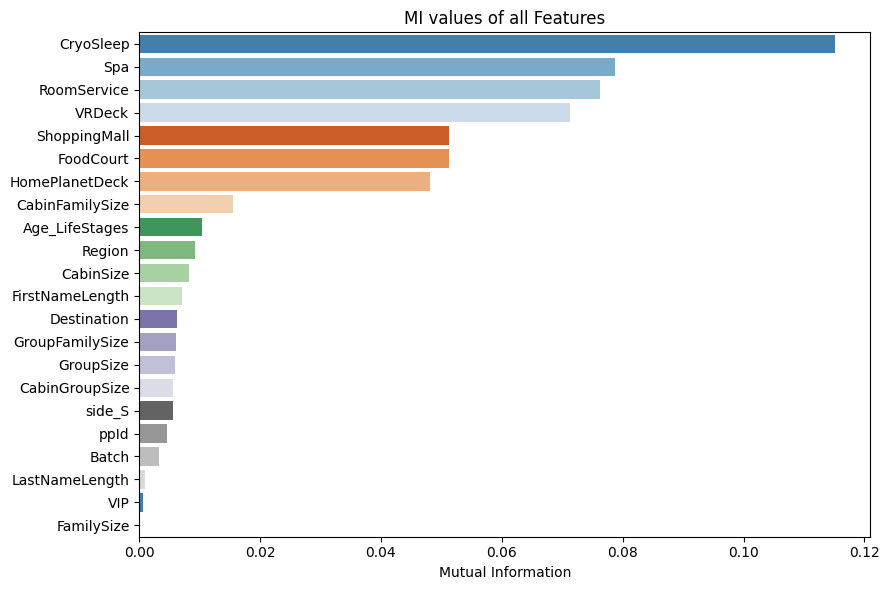

In [7]:
MI = fi.mutual_info(random_state = 78)
plot_Importance(MI, 'Mutual Information', 'MI', topk = 'all', palette = 'tab20c')

In [8]:
cutoffs = [0.3, 0.1, 0.05, 0, 'All']
Features_Dict = {}
for ratio in cutoffs:
    if ratio == 'All':
        Features_Dict['All'] = X[MI.index.tolist()]
    elif ratio == 0:
        Features_Dict['MI ≠ 0'] = X[MI[MI > 0.0].index.tolist()]
    else:
        Top_Features = MI[MI >= ratio*MI.max()].index.tolist()
        Features_Dict[f'MI ≥ {ratio*MI.max():.3f}'] = X[Top_Features]

In [9]:
scoring = {
    'accuracy': accuracy_score, 
    'roc_auc': roc_auc_score,
    'f1_pos': lambda y_true,  y_pred: f1_score(y_true, y_pred, pos_label = 1), 
    'f1_neg': lambda y_true, y_pred: f1_score(y_true, y_pred, pos_label = 0),
    'precision_pos': lambda y_true, y_pred: precision_score(y_true, y_pred, pos_label = 1),
    'precision_neg': lambda y_true, y_pred: precision_score(y_true, y_pred, pos_label = 0),
    'recall_pos': lambda y_true, y_pred: recall_score(y_true, y_pred, pos_label = 1),
    'recall_neg': lambda y_true, y_pred: recall_score(y_true, y_pred, pos_label = 0)
}

Results, Results_summary, catboost_importance = Get_FSelect_Results(Features_Dict, y, scoring, cat_features = Nominal_Categorical_Features, Kfold = 10, random_state = 78)

MI ≥ 0.035: ['CryoSleep', 'Spa', 'RoomService', 'VRDeck', 'ShoppingMall', 'FoodCourt', 'HomePlanetDeck']
MI ≥ 0.012: ['CryoSleep', 'Spa', 'RoomService', 'VRDeck', 'ShoppingMall', 'FoodCourt', 'HomePlanetDeck', 'CabinFamilySize']
MI ≥ 0.006: ['CryoSleep', 'Spa', 'RoomService', 'VRDeck', 'ShoppingMall', 'FoodCourt', 'HomePlanetDeck', 'CabinFamilySize', 'Age_LifeStages', 'Region', 'CabinSize', 'FirstNameLength', 'Destination', 'GroupFamilySize', 'GroupSize']
MI ≠ 0: ['CryoSleep', 'Spa', 'RoomService', 'VRDeck', 'ShoppingMall', 'FoodCourt', 'HomePlanetDeck', 'CabinFamilySize', 'Age_LifeStages', 'Region', 'CabinSize', 'FirstNameLength', 'Destination', 'GroupFamilySize', 'GroupSize', 'CabinGroupSize', 'side_S', 'ppId', 'Batch', 'LastNameLength', 'VIP']
All: ['CryoSleep', 'Spa', 'RoomService', 'VRDeck', 'ShoppingMall', 'FoodCourt', 'HomePlanetDeck', 'CabinFamilySize', 'Age_LifeStages', 'Region', 'CabinSize', 'FirstNameLength', 'Destination', 'GroupFamilySize', 'GroupSize', 'CabinGroupSize', '

In [10]:
style_results(Results, only_mean = True)

,MI ≥ 0.035,MI ≥ 0.012,MI ≥ 0.006,MI ≠ 0,All
accuracy,0.8025,0.8024,0.8049,0.8081,0.8100
roc_auc,0.8023,0.8022,0.8047,0.8080,0.8098
f1_pos,0.8092,0.8095,0.8112,0.8134,0.8146
f1_neg,0.7951,0.7947,0.7981,0.8024,0.8049
precision_pos,0.7879,0.7869,0.7914,0.7977,0.8012
precision_neg,0.8197,0.8208,0.8207,0.8205,0.8203
recall_pos,0.8321,0.8338,0.8323,0.8303,0.8290
recall_neg,0.7724,0.7706,0.7771,0.7856,0.7906
time (sec),86.3133,94.1553,144.1642,157.4724,148.8157


In [11]:
Results_summary

,MI ≥ 0.035,MI ≥ 0.012,MI ≥ 0.006,MI ≠ 0,All
accuracy,0.8025 ± 0.0130,0.8024 ± 0.0132,0.8049 ± 0.0130,0.8081 ± 0.0139,0.8100 ± 0.0140
roc_auc,0.8023 ± 0.0130,0.8022 ± 0.0132,0.8047 ± 0.0130,0.8080 ± 0.0140,0.8098 ± 0.0140
f1_pos,0.8092 ± 0.0132,0.8095 ± 0.0131,0.8112 ± 0.0124,0.8134 ± 0.0128,0.8146 ± 0.0129
f1_neg,0.7951 ± 0.0138,0.7947 ± 0.0141,0.7981 ± 0.0143,0.8024 ± 0.0159,0.8049 ± 0.0160
precision_pos,0.7879 ± 0.0148,0.7869 ± 0.0147,0.7914 ± 0.0159,0.7977 ± 0.0194,0.8012 ± 0.0198
precision_neg,0.8197 ± 0.0182,0.8208 ± 0.0176,0.8207 ± 0.0160,0.8205 ± 0.0157,0.8203 ± 0.0155
recall_pos,0.8321 ± 0.0217,0.8338 ± 0.0202,0.8323 ± 0.0185,0.8303 ± 0.0187,0.8290 ± 0.0186
recall_neg,0.7724 ± 0.0206,0.7706 ± 0.0200,0.7771 ± 0.0217,0.7856 ± 0.0262,0.7906 ± 0.0266


In [12]:
Results_test = pd.DataFrame(index = ['test_accuracy'], columns = list(Features_Dict.keys()))
Results_test.loc['test_accuracy', :] = [0.79471, 0.79565, 0.79822, 0.81014, 0.80687]
style_results(Results_test, only_mean = True)

,MI ≥ 0.035,MI ≥ 0.012,MI ≥ 0.006,MI ≠ 0,All
test_accuracy,0.7947,0.7956,0.7982,0.8101,0.8069


In [13]:
catboost_importance

,Importances mean,Importance std
Feature Id,,
HomePlanetDeck,22.210243,3.132045
CryoSleep,12.584999,4.948348
Spa,11.875433,0.735475
VRDeck,10.625393,0.694019
RoomService,9.008058,0.994056
FoodCourt,6.888617,0.330932
side_S,4.348412,0.678084
Region,3.947194,1.578686
Age_LifeStages,3.249759,0.580663


# Embedded Feature Importance

In [14]:
EFI = fi.catboost_emb()

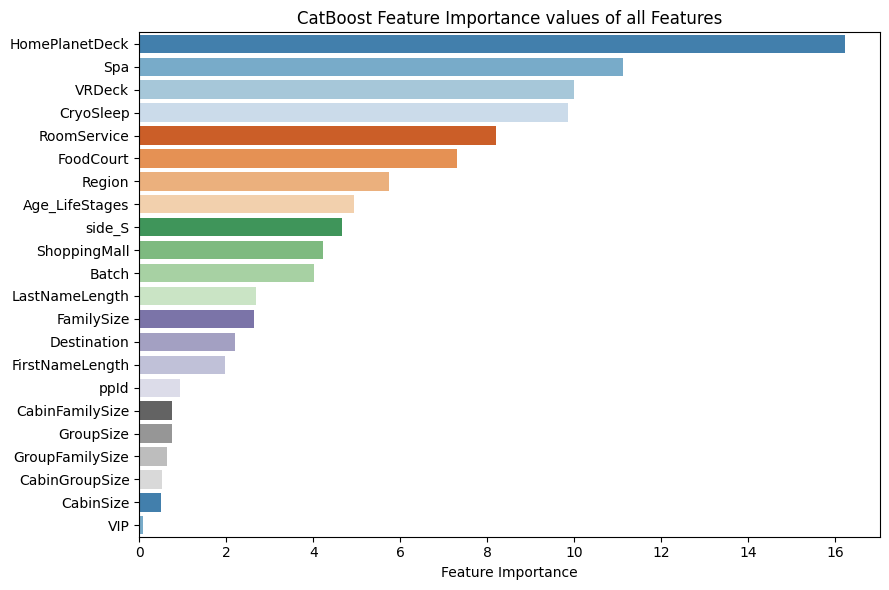

In [15]:
plot_Importance(EFI.squeeze("columns"), 'Feature Importance', 'CatBoost Feature Importance', topk = 'all', palette = 'tab20c')

In [16]:
cutoffs = [0.1, 0.01, 0]
Features_Dict = {}
for ratio in cutoffs:
    if ratio == 'All':
        Features_Dict['All'] = X[EFI.index.tolist()]
    elif ratio == 0:
        Features_Dict['EFI ≠ 0'] = X[EFI[EFI.Importances > 0.0].index.tolist()]
    else:
        Top_Features = EFI[EFI.Importances >= ratio*EFI.Importances.max()].index.tolist()
        Features_Dict[f'EFI ≥ {ratio*EFI.Importances.max():.3f}'] = X[Top_Features]

In [17]:
Results, Results_summary = Get_FSelect_Results(Features_Dict, y, scoring, cat_features = Nominal_Categorical_Features, Kfold = 10, random_state = 78)

EFI ≥ 1.622: ['HomePlanetDeck', 'Spa', 'VRDeck', 'CryoSleep', 'RoomService', 'FoodCourt', 'Region', 'Age_LifeStages', 'side_S', 'ShoppingMall', 'Batch', 'LastNameLength', 'FamilySize', 'Destination', 'FirstNameLength']
EFI ≥ 0.162: ['HomePlanetDeck', 'Spa', 'VRDeck', 'CryoSleep', 'RoomService', 'FoodCourt', 'Region', 'Age_LifeStages', 'side_S', 'ShoppingMall', 'Batch', 'LastNameLength', 'FamilySize', 'Destination', 'FirstNameLength', 'ppId', 'CabinFamilySize', 'GroupSize', 'GroupFamilySize', 'CabinGroupSize', 'CabinSize']
EFI ≠ 0: ['HomePlanetDeck', 'Spa', 'VRDeck', 'CryoSleep', 'RoomService', 'FoodCourt', 'Region', 'Age_LifeStages', 'side_S', 'ShoppingMall', 'Batch', 'LastNameLength', 'FamilySize', 'Destination', 'FirstNameLength', 'ppId', 'CabinFamilySize', 'GroupSize', 'GroupFamilySize', 'CabinGroupSize', 'CabinSize', 'VIP']


In [18]:
style_results(Results, only_mean = True)

,EFI ≥ 1.622,EFI ≥ 0.162,EFI ≠ 0
accuracy,0.8153,0.8171,0.8175
roc_auc,0.8152,0.8170,0.8174
f1_pos,0.8182,0.8199,0.8204
f1_neg,0.8122,0.8142,0.8144
precision_pos,0.8112,0.8137,0.8136
precision_neg,0.8198,0.8211,0.8221
recall_pos,0.8255,0.8264,0.8276
recall_neg,0.8049,0.8077,0.8073
time (sec),143.8854,159.8060,135.9772


In [19]:
Results_summary

,EFI ≥ 1.622,EFI ≥ 0.162,EFI ≠ 0
accuracy,0.8153 ± 0.0109,0.8171 ± 0.0120,0.8175 ± 0.0124
roc_auc,0.8152 ± 0.0109,0.8170 ± 0.0120,0.8174 ± 0.0124
f1_pos,0.8182 ± 0.0103,0.8199 ± 0.0114,0.8204 ± 0.0117
f1_neg,0.8122 ± 0.0117,0.8142 ± 0.0131,0.8144 ± 0.0134
precision_pos,0.8112 ± 0.0141,0.8137 ± 0.0163,0.8136 ± 0.0168
precision_neg,0.8198 ± 0.0112,0.8211 ± 0.0131,0.8221 ± 0.0140
recall_pos,0.8255 ± 0.0126,0.8264 ± 0.0150,0.8276 ± 0.0160
recall_neg,0.8049 ± 0.0172,0.8077 ± 0.0202,0.8073 ± 0.0210


In [20]:
Results_test = pd.DataFrame(index = ['test_accuracy'], columns = list(Features_Dict.keys()))
Results_test.loc['test_accuracy', :] = [0.80874, 0.80874, 0.80827]
style_results(Results_test, only_mean = True)

,EFI ≥ 1.622,EFI ≥ 0.162,EFI ≠ 0
test_accuracy,0.8087,0.8087,0.8083


# Feature Selection Based on Lasso Cross Validation

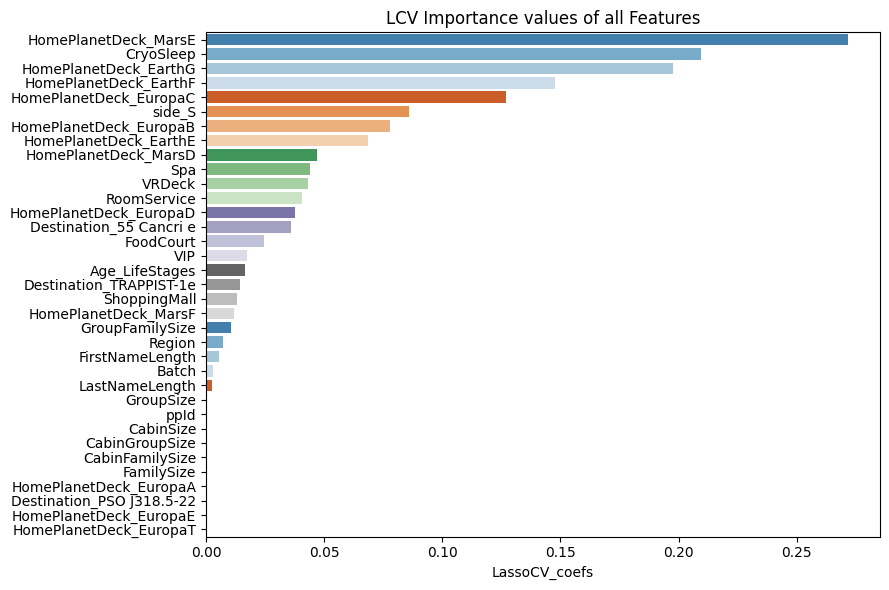

In [21]:
LCV = fi.LCV_importance()
plot_Importance(LCV, 'LassoCV_coefs', 'LCV Importance', topk = 'all', palette = 'tab20c')

In [22]:
cutoffs = [0.3, 0.1, 0.05, 0, 'All']
Features_Dict = {}
for ratio in cutoffs:
    if ratio == 'All':
        Features_Dict['All'] = X[LCV.index.tolist()]
    elif ratio == 0:
        Features_Dict['LCV ≠ 0'] = X[LCV[LCV > 0.0].index.tolist()]
    else:
        Top_Features = LCV[LCV >= ratio*LCV.max()].index.tolist()
        Features_Dict[f'LCV ≥ {ratio*LCV.max():.3f}'] = X[Top_Features]

In [23]:
Results, Results_summary, catboost_importance = Get_FSelect_Results(Features_Dict, y, scoring, cat_features = None, Kfold = 10, random_state = 78)

LCV ≥ 0.081: ['HomePlanetDeck_MarsE', 'CryoSleep', 'HomePlanetDeck_EarthG', 'HomePlanetDeck_EarthF', 'HomePlanetDeck_EuropaC', 'side_S']
LCV ≥ 0.027: ['HomePlanetDeck_MarsE', 'CryoSleep', 'HomePlanetDeck_EarthG', 'HomePlanetDeck_EarthF', 'HomePlanetDeck_EuropaC', 'side_S', 'HomePlanetDeck_EuropaB', 'HomePlanetDeck_EarthE', 'HomePlanetDeck_MarsD', 'Spa', 'VRDeck', 'RoomService', 'HomePlanetDeck_EuropaD', 'Destination_55 Cancri e']
LCV ≥ 0.014: ['HomePlanetDeck_MarsE', 'CryoSleep', 'HomePlanetDeck_EarthG', 'HomePlanetDeck_EarthF', 'HomePlanetDeck_EuropaC', 'side_S', 'HomePlanetDeck_EuropaB', 'HomePlanetDeck_EarthE', 'HomePlanetDeck_MarsD', 'Spa', 'VRDeck', 'RoomService', 'HomePlanetDeck_EuropaD', 'Destination_55 Cancri e', 'FoodCourt', 'VIP', 'Age_LifeStages', 'Destination_TRAPPIST-1e']
LCV ≠ 0: ['HomePlanetDeck_MarsE', 'CryoSleep', 'HomePlanetDeck_EarthG', 'HomePlanetDeck_EarthF', 'HomePlanetDeck_EuropaC', 'side_S', 'HomePlanetDeck_EuropaB', 'HomePlanetDeck_EarthE', 'HomePlanetDeck_Mars

In [24]:
style_results(Results, only_mean = True)

,LCV ≥ 0.081,LCV ≥ 0.027,LCV ≥ 0.014,LCV ≠ 0,All
accuracy,0.7300,0.7668,0.7808,0.7902,0.7961
roc_auc,0.7309,0.7672,0.7809,0.7903,0.7962
f1_pos,0.6943,0.7524,0.7731,0.7855,0.7930
f1_neg,0.7582,0.7772,0.7856,0.7927,0.7974
precision_pos,0.8081,0.7983,0.7976,0.8007,0.8035
precision_neg,0.6826,0.7519,0.7756,0.7887,0.7961
recall_pos,0.6089,0.7214,0.7589,0.7783,0.7889
recall_neg,0.8528,0.8129,0.8029,0.8023,0.8034
time (sec),31.4506,68.7535,69.7772,66.5456,82.5106


In [25]:
Results_summary

,LCV ≥ 0.081,LCV ≥ 0.027,LCV ≥ 0.014,LCV ≠ 0,All
accuracy,0.7300 ± 0.0132,0.7668 ± 0.0389,0.7808 ± 0.0380,0.7902 ± 0.0372,0.7961 ± 0.0357
roc_auc,0.7309 ± 0.0132,0.7672 ± 0.0384,0.7809 ± 0.0375,0.7903 ± 0.0368,0.7962 ± 0.0354
f1_pos,0.6943 ± 0.0152,0.7524 ± 0.0596,0.7731 ± 0.0571,0.7855 ± 0.0543,0.7930 ± 0.0510
f1_neg,0.7582 ± 0.0125,0.7772 ± 0.0228,0.7856 ± 0.0234,0.7927 ± 0.0246,0.7974 ± 0.0247
precision_pos,0.8081 ± 0.0220,0.7983 ± 0.0206,0.7976 ± 0.0190,0.8007 ± 0.0188,0.8035 ± 0.0191
precision_neg,0.6826 ± 0.0112,0.7519 ± 0.0704,0.7756 ± 0.0670,0.7887 ± 0.0627,0.7961 ± 0.0582
recall_pos,0.6089 ± 0.0185,0.7214 ± 0.1137,0.7589 ± 0.1072,0.7783 ± 0.0990,0.7889 ± 0.0913
recall_neg,0.8528 ± 0.0204,0.8129 ± 0.0442,0.8029 ± 0.0405,0.8023 ± 0.0363,0.8034 ± 0.0337


In [26]:
Results_test = pd.DataFrame(index = ['test_accuracy'], columns = list(Features_Dict.keys()))
Results_test.loc['test_accuracy', :] = [0.73415, 0.79261, 0.79869, 0.80734, 0.80617]
style_results(Results_test, only_mean = True)

,LCV ≥ 0.081,LCV ≥ 0.027,LCV ≥ 0.014,LCV ≠ 0,All
test_accuracy,0.7341,0.7926,0.7987,0.8073,0.8062


In [27]:
# catboost_importance

# Permutation Importance

In [28]:
PI = fi.catboost_perm_importance_cv()

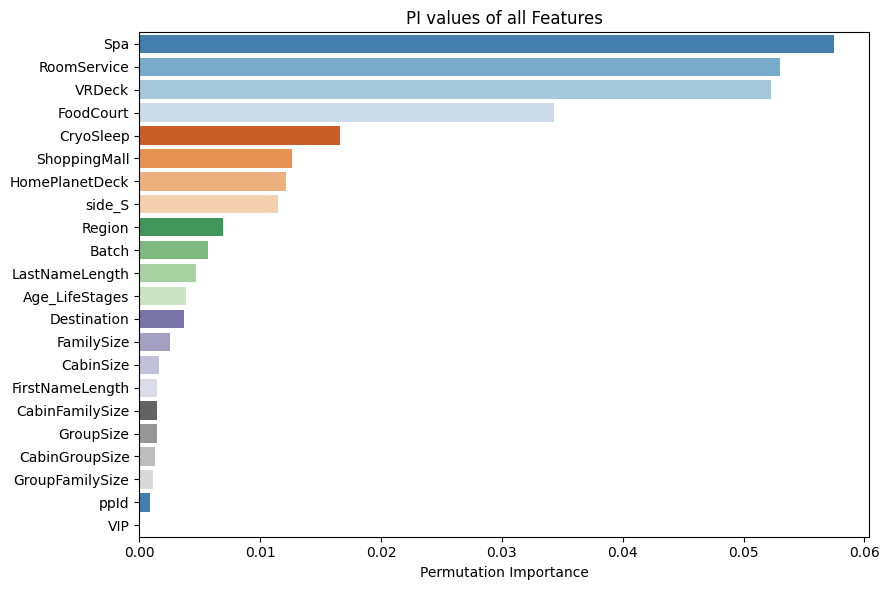

In [29]:
plot_Importance(PI, 'Permutation Importance', 'PI', topk = 'all', palette = 'tab20c')

In [30]:
cutoffs = [0.03, 0.001, 0]
Features_Dict = {}
for ratio in cutoffs:
    if ratio == 'All':
        Features_Dict['All'] = X[PI.index.tolist()]
    elif ratio == 0:
        Features_Dict['PI ≠ 0'] = X[PI[PI > 0.0].index.tolist()]
    else:
        Top_Features = PI[PI >= ratio*PI.max()].index.tolist()
        Features_Dict[f'PI ≥ {ratio*PI.max():.3f}'] = X[Top_Features]

Results, Results_summary = Get_FSelect_Results(Features_Dict, y, scoring, cat_features = Nominal_Categorical_Features, Kfold = 10, random_state = 78)
style_results(Results, only_mean = True)

PI ≥ 0.002: ['Spa', 'RoomService', 'VRDeck', 'FoodCourt', 'CryoSleep', 'ShoppingMall', 'HomePlanetDeck', 'side_S', 'Region', 'Batch', 'LastNameLength', 'Age_LifeStages', 'Destination', 'FamilySize']
PI ≥ 0.000: ['Spa', 'RoomService', 'VRDeck', 'FoodCourt', 'CryoSleep', 'ShoppingMall', 'HomePlanetDeck', 'side_S', 'Region', 'Batch', 'LastNameLength', 'Age_LifeStages', 'Destination', 'FamilySize', 'CabinSize', 'FirstNameLength', 'CabinFamilySize', 'GroupSize', 'CabinGroupSize', 'GroupFamilySize', 'ppId']
PI ≠ 0: ['Spa', 'RoomService', 'VRDeck', 'FoodCourt', 'CryoSleep', 'ShoppingMall', 'HomePlanetDeck', 'side_S', 'Region', 'Batch', 'LastNameLength', 'Age_LifeStages', 'Destination', 'FamilySize', 'CabinSize', 'FirstNameLength', 'CabinFamilySize', 'GroupSize', 'CabinGroupSize', 'GroupFamilySize', 'ppId', 'VIP']


,PI ≥ 0.002,PI ≥ 0.000,PI ≠ 0
accuracy,0.8193,0.8183,0.8181
roc_auc,0.8192,0.8182,0.8181
f1_pos,0.8216,0.8208,0.8207
f1_neg,0.8169,0.8156,0.8154
precision_pos,0.8173,0.8157,0.8151
precision_neg,0.8219,0.8217,0.8218
recall_pos,0.8262,0.8264,0.8268
recall_neg,0.8123,0.8101,0.8094
time (sec),124.0057,141.7817,112.7739


In [31]:
Results_summary

,PI ≥ 0.002,PI ≥ 0.000,PI ≠ 0
accuracy,0.8193 ± 0.0130,0.8183 ± 0.0116,0.8181 ± 0.0118
roc_auc,0.8192 ± 0.0130,0.8182 ± 0.0116,0.8181 ± 0.0119
f1_pos,0.8216 ± 0.0129,0.8208 ± 0.0113,0.8207 ± 0.0116
f1_neg,0.8169 ± 0.0137,0.8156 ± 0.0126,0.8154 ± 0.0127
precision_pos,0.8173 ± 0.0167,0.8157 ± 0.0168,0.8151 ± 0.0161
precision_neg,0.8219 ± 0.0158,0.8217 ± 0.0146,0.8218 ± 0.0147
recall_pos,0.8262 ± 0.0186,0.8264 ± 0.0180,0.8268 ± 0.0177
recall_neg,0.8123 ± 0.0207,0.8101 ± 0.0217,0.8094 ± 0.0206


In [32]:
Results_test = pd.DataFrame(index = ['test_accuracy'], columns = list(Features_Dict.keys()))
Results_test.loc['test_accuracy', :] = [0.81155, 0.81131, 0.80851]
style_results(Results_test, only_mean = True)

,PI ≥ 0.002,PI ≥ 0.000,PI ≠ 0
test_accuracy,0.8115,0.8113,0.8085


# Recursive Feature Elimination Cross Validation

In [33]:
rfecv_Selected_Features = fi.catboost_rfecv()
print(f'Number of Selected Features = {len(rfecv_Selected_Features)}')
print(f'Selected Features = {rfecv_Selected_Features}')

Number of Selected Features = 4
Selected Features = ['RoomService' 'Spa' 'VRDeck' 'HomePlanetDeck']


In [34]:
Features_Dict = {
    'RFECV features': X[rfecv_Selected_Features], 
    'All features': X[PI.index.tolist()]
}

Results, Results_summary = Get_FSelect_Results(Features_Dict, y, scoring, cat_features = Nominal_Categorical_Features, Kfold = 10, random_state = 78)
style_results(Results, only_mean = True)

RFECV features: ['RoomService', 'Spa', 'VRDeck', 'HomePlanetDeck']
All features: ['Spa', 'RoomService', 'VRDeck', 'FoodCourt', 'CryoSleep', 'ShoppingMall', 'HomePlanetDeck', 'side_S', 'Region', 'Batch', 'LastNameLength', 'Age_LifeStages', 'Destination', 'FamilySize', 'CabinSize', 'FirstNameLength', 'CabinFamilySize', 'GroupSize', 'CabinGroupSize', 'GroupFamilySize', 'ppId', 'VIP']


,RFECV features,All features
accuracy,0.7953,0.8066
roc_auc,0.7951,0.8064
f1_pos,0.8039,0.8122
f1_neg,0.7860,0.8004
precision_pos,0.7771,0.7956
precision_neg,0.8171,0.8196
recall_pos,0.8328,0.8302
recall_neg,0.7574,0.7826
time (sec),100.1687,111.2509


In [35]:
Results_summary

,RFECV features,All features
accuracy,0.7953 ± 0.0123,0.8066 ± 0.0166
roc_auc,0.7951 ± 0.0123,0.8064 ± 0.0167
f1_pos,0.8039 ± 0.0112,0.8122 ± 0.0144
f1_neg,0.7860 ± 0.0141,0.8004 ± 0.0197
precision_pos,0.7771 ± 0.0147,0.7956 ± 0.0235
precision_neg,0.8171 ± 0.0136,0.8196 ± 0.0145
recall_pos,0.8328 ± 0.0149,0.8302 ± 0.0162
recall_neg,0.7574 ± 0.0206,0.7826 ± 0.0318


In [36]:
Results_test = pd.DataFrame(index = ['test_accuracy'], columns = ['RFECV features', 'All features'])
Results_test.loc['test_accuracy', :] = [0.78700, 0.80851]
style_results(Results_test, only_mean = True)

,RFECV features,All features
test_accuracy,0.7870,0.8085


# Principal Component Analysis

In [37]:
Features_Dict = {}
for v in [0.9, 0.95, 0.99, 1.0]:
    key_name = 'All features' if v == 1.0 else f'PCA_{v} features'
    Features_Dict[key_name] = fi.Get_PCA_Input(v)

In [38]:
Results, Results_summary = Get_FSelect_Results(Features_Dict, y, scoring, Kfold = 10, random_state = 78)
style_results(Results, only_mean = True)

PCA_0.9 features: (8693, 15)
PCA_0.95 features: (8693, 18)
PCA_0.99 features: (8693, 25)
All features: (8693, 35)


,PCA_0.9 features,PCA_0.95 features,PCA_0.99 features,All features
accuracy,0.7981,0.8001,0.8035,0.8077
roc_auc,0.7980,0.8001,0.8035,0.8077
f1_pos,0.8017,0.8028,0.8054,0.8101
f1_neg,0.7943,0.7972,0.8014,0.8052
precision_pos,0.7938,0.7981,0.8038,0.8062
precision_neg,0.8034,0.8028,0.8037,0.8099
recall_pos,0.8102,0.8080,0.8073,0.8144
recall_neg,0.7859,0.7921,0.7996,0.8009
time (sec),92.9661,111.7094,144.5605,87.4336


In [39]:
Results_summary

,PCA_0.9 features,PCA_0.95 features,PCA_0.99 features,All features
accuracy,0.7981 ± 0.0135,0.8001 ± 0.0132,0.8035 ± 0.0122,0.8077 ± 0.0140
roc_auc,0.7980 ± 0.0136,0.8001 ± 0.0132,0.8035 ± 0.0123,0.8077 ± 0.0140
f1_pos,0.8017 ± 0.0127,0.8028 ± 0.0124,0.8054 ± 0.0114,0.8101 ± 0.0138
f1_neg,0.7943 ± 0.0152,0.7972 ± 0.0147,0.8014 ± 0.0138,0.8052 ± 0.0148
precision_pos,0.7938 ± 0.0186,0.7981 ± 0.0180,0.8038 ± 0.0174,0.8062 ± 0.0172
precision_neg,0.8034 ± 0.0151,0.8028 ± 0.0144,0.8037 ± 0.0131,0.8099 ± 0.0169
recall_pos,0.8102 ± 0.0180,0.8080 ± 0.0174,0.8073 ± 0.0161,0.8144 ± 0.0200
recall_neg,0.7859 ± 0.0245,0.7921 ± 0.0235,0.7996 ± 0.0228,0.8009 ± 0.0219


# Hyperparameter Optimization

In [40]:
Top_Features = PI[PI >= 0.03*PI.max()].index.tolist()

In [41]:
# optuna.logging.set_verbosity(optuna.logging.WARNING)
# best_params = Get_Optimal_Parameters(X[Top_Features], y, 'CatBoost', cat_features = Nominal_Categorical_Features)
# print(best_params)

In [42]:
params = {
    'iterations': 5000, 
    'learning_rate': 0.02, 
    'od_wait': 500, 
    'eval_metric': 'Accuracy', 
    'bootstrap_type': 'Bayesian', 
    'loss_function': 'Logloss', 
    'auto_class_weights': 'Balanced',
    'depth': 7,
    'min_data_in_leaf': 31,
    'leaf_estimation_iterations': 17,
    'l2_leaf_reg': 3,
    'bagging_temperature': 0.2,
    'rsm': 0.9,
    'random_strength': 1.8
}

Results, Results_summary = Get_FSelect_Results({'PI_Opt': X[Top_Features]}, y, scoring, cat_features = Nominal_Categorical_Features, df_test = X_test, Kfold = 10, repeats = 3, default = False, best_params = params)
Results_summary

PI_Opt: ['Spa', 'RoomService', 'VRDeck', 'FoodCourt', 'CryoSleep', 'ShoppingMall', 'HomePlanetDeck', 'side_S', 'Region', 'Batch', 'LastNameLength', 'Age_LifeStages', 'Destination', 'FamilySize']


,PI_Opt
accuracy,0.8195 ± 0.0118
roc_auc,0.8195 ± 0.0118
f1_pos,0.8216 ± 0.0118
f1_neg,0.8173 ± 0.0124
precision_pos,0.8181 ± 0.0151
precision_neg,0.8215 ± 0.0150
recall_pos,0.8255 ± 0.0183
recall_neg,0.8134 ± 0.0194


Test Accuracy = 0.81178